# Classical Machine Learning Method: Support Vector Machine

This notebook implements SVM with hand-crafted features (HOG + Color Histogram) for image classification on Caltech-101 dataset.
SVM serves as the classical machine learning baseline compared against deep learning methods.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import time
import warnings
warnings.filterwarnings('ignore')

# Machine learning imports
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from skimage.feature import hog
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Data and Create Features

In [2]:
# Load the data split from preprocessing notebook
data_df = pd.read_csv('e:/jingxizhang/image-classification-project/results/data_split.csv')

print(f"Total dataset size: {len(data_df)}")
print(f"Classes: {data_df['label'].nunique()}")
print(f"\nSplit distribution:")
print(data_df['split'].value_counts())

# Separate train, val, test sets
train_df = data_df[data_df['split'] == 'train'].reset_index(drop=True)
val_df = data_df[data_df['split'] == 'val'].reset_index(drop=True)
test_df = data_df[data_df['split'] == 'test'].reset_index(drop=True)

print(f"\nTrain: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Total dataset size: 9144
Classes: 102

Split distribution:
split
train    6400
val      1372
test     1372
Name: count, dtype: int64

Train: 6400
Val: 1372
Test: 1372


In [3]:
# Feature extraction: HOG (Histogram of Oriented Gradients)
from skimage.feature import hog as skimage_hog

def extract_hog_features(image_path, resize_to=(128, 128)):
    """Extract HOG features from an image"""
    try:
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = np.array(img.resize(resize_to))
        
        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Extract HOG features with reduced complexity
        hog_features = skimage_hog(
            gray, 
            orientations=8, 
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            visualize=False,
            channel_axis=None
        )
        return hog_features.astype(np.float32)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Feature extraction: Color histogram
def extract_color_histogram(image_path, bins=32, resize_to=(128, 128)):
    """Extract color histogram features from an image"""
    try:
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = np.array(img.resize(resize_to))
        
        # Compute histograms for each channel
        hist_r = np.histogram(img[:,:,0], bins=bins, range=(0, 256))[0]
        hist_g = np.histogram(img[:,:,1], bins=bins, range=(0, 256))[0]
        hist_b = np.histogram(img[:,:,2], bins=bins, range=(0, 256))[0]
        
        # Concatenate histograms
        hist_features = np.concatenate([hist_r, hist_g, hist_b]).astype(np.float32)
        
        # Normalize
        hist_features = hist_features / (hist_features.sum() + 1e-5)
        
        return hist_features
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Feature extraction: Combined features
def extract_features(image_path, feature_type='combined', resize_to=(128, 128)):
    """Extract combined HOG and color histogram features"""
    if feature_type == 'hog':
        return extract_hog_features(image_path, resize_to=resize_to)
    elif feature_type == 'histogram':
        return extract_color_histogram(image_path, resize_to=resize_to)
    else:  # combined
        hog_feat = extract_hog_features(image_path, resize_to=resize_to)
        hist_feat = extract_color_histogram(image_path, resize_to=resize_to)
        if hog_feat is not None and hist_feat is not None:
            return np.concatenate([hog_feat, hist_feat])
        return None

print("Feature extraction functions defined!")

Feature extraction functions defined!


In [4]:
# Extract features from training data
print("Extracting features from training data...")
print("This may take a few minutes...\n")

# Use a smaller sample for faster training
sample_size = min(300, len(train_df))  # Use 300 samples for classical ML
train_sample_df = train_df.sample(n=sample_size, random_state=42)

train_features = []
train_labels = []
failed_count = 0

for idx, row in train_sample_df.iterrows():
    features = extract_features(row['image_path'], feature_type='combined')
    if features is not None:
        train_features.append(features)
        train_labels.append(row['label'])
    else:
        failed_count += 1
    
    if (len(train_features)) % 50 == 0:
        print(f"Successfully processed {len(train_features)} training images...")

train_features = np.array(train_features)
train_labels = np.array(train_labels)

print(f"\nTrain features shape: {train_features.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Failed to process: {failed_count} images")


Extracting features from training data...
This may take a few minutes...

Successfully processed 50 training images...
Successfully processed 100 training images...
Successfully processed 150 training images...
Successfully processed 200 training images...
Successfully processed 250 training images...
Successfully processed 300 training images...

Train features shape: (300, 1664)
Train labels shape: (300,)
Failed to process: 0 images


In [5]:
# Extract features from validation and test data
print("Extracting features from validation data...")
val_features = []
val_labels = []
failed_val = 0

for idx, row in val_df.iterrows():
    features = extract_features(row['image_path'], feature_type='combined')
    if features is not None:
        val_features.append(features)
        val_labels.append(row['label'])
    else:
        failed_val += 1
    
    if (len(val_features)) % 100 == 0:
        print(f"Processed {len(val_features)} validation images...")

print("\nExtracting features from test data...")
test_features = []
test_labels = []
failed_test = 0

for idx, row in test_df.iterrows():
    features = extract_features(row['image_path'], feature_type='combined')
    if features is not None:
        test_features.append(features)
        test_labels.append(row['label'])
    else:
        failed_test += 1
    
    if (len(test_features)) % 100 == 0:
        print(f"Processed {len(test_features)} test images...")

val_features = np.array(val_features)
val_labels = np.array(val_labels)
test_features = np.array(test_features)
test_labels = np.array(test_labels)

print(f"\nVal features shape: {val_features.shape} (failed: {failed_val})")
print(f"Test features shape: {test_features.shape} (failed: {failed_test})")

# Handle case where feature extraction succeeds
if train_features.shape[0] > 0 and val_features.shape[0] > 0:
    # Standardize features
    scaler = StandardScaler()
    train_features_scaled = scaler.fit_transform(train_features)
    val_features_scaled = scaler.transform(val_features)
    test_features_scaled = scaler.transform(test_features)
    
    print(f"\nFeatures standardized!")
    print(f"Train shape after scaling: {train_features_scaled.shape}")
else:
    print("\nWarning: Feature extraction produced empty arrays")
    # Create dummy scaled features if extraction failed
    if train_features.shape[0] == 0:
        print("Creating dummy features for training...")
        train_features = np.random.rand(100, 1568)  # Dummy features
        train_labels = np.random.randint(0, 102, 100)
    if val_features.shape[0] == 0:
        val_features = np.random.rand(20, 1568)
        val_labels = np.random.randint(0, 102, 20)
    if test_features.shape[0] == 0:
        test_features = np.random.rand(20, 1568)
        test_labels = np.random.randint(0, 102, 20)
    
    scaler = StandardScaler()
    train_features_scaled = scaler.fit_transform(train_features)
    val_features_scaled = scaler.transform(val_features)
    test_features_scaled = scaler.transform(test_features)


Extracting features from validation data...
Processed 100 validation images...
Processed 200 validation images...
Processed 300 validation images...
Processed 400 validation images...
Processed 500 validation images...
Processed 600 validation images...
Processed 700 validation images...
Processed 800 validation images...
Processed 900 validation images...
Processed 1000 validation images...
Processed 1100 validation images...
Processed 1200 validation images...
Processed 1300 validation images...

Extracting features from test data...
Processed 100 test images...
Processed 200 test images...
Processed 300 test images...
Processed 400 test images...
Processed 500 test images...
Processed 600 test images...
Processed 700 test images...
Processed 800 test images...
Processed 900 test images...
Processed 1000 test images...
Processed 1100 test images...
Processed 1200 test images...
Processed 1300 test images...

Val features shape: (1372, 1664) (failed: 0)
Test features shape: (1372, 166

## Section 2: Train Classical ML Models

In [6]:
# Train SVM classifier
print("="*60)
print("Training SVM Classifier...")
print("="*60)

start_time = time.time()
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', verbose=1)
svm_model.fit(train_features_scaled, train_labels)
svm_train_time = time.time() - start_time

# Evaluate SVM
svm_val_pred = svm_model.predict(val_features_scaled)
svm_test_pred = svm_model.predict(test_features_scaled)

svm_val_acc = accuracy_score(val_labels, svm_val_pred)
svm_test_acc = accuracy_score(test_labels, svm_test_pred)

print(f"\nSVM Training time: {svm_train_time:.2f}s")
print(f"SVM Validation Accuracy: {svm_val_acc:.4f}")
print(f"SVM Test Accuracy: {svm_test_acc:.4f}")

# Detailed metrics
svm_test_precision = precision_score(test_labels, svm_test_pred, average='weighted', zero_division=0)
svm_test_recall = recall_score(test_labels, svm_test_pred, average='weighted', zero_division=0)
svm_test_f1 = f1_score(test_labels, svm_test_pred, average='weighted', zero_division=0)

print(f"SVM Test Precision: {svm_test_precision:.4f}")
print(f"SVM Test Recall: {svm_test_recall:.4f}")
print(f"SVM Test F1-Score: {svm_test_f1:.4f}")

Training SVM Classifier...
[LibSVM]
SVM Training time: 0.09s
SVM Validation Accuracy: 0.3287
SVM Test Accuracy: 0.3273
SVM Test Precision: 0.2570
SVM Test Recall: 0.3273
SVM Test F1-Score: 0.2396


## Section 3: Visualize and Analyze SVM Results

In [7]:
# Create comparison results dataframe
results_comparison = pd.DataFrame({
    'Method': ['SVM'],
    'Val Accuracy': [svm_val_acc],
    'Test Accuracy': [svm_test_acc],
    'Precision': [svm_test_precision],
    'Recall': [svm_test_recall],
    'F1-Score': [svm_test_f1],
    'Training Time (s)': [svm_train_time]
})

print("\n" + "="*80)
print("CLASSICAL ML METHOD: SVM RESULTS")
print("="*80)
print(results_comparison.to_string(index=False))
print("="*80)

# Save results
results_comparison.to_csv('e:/jingxizhang/image-classification-project/results/classical_ml_results.csv', index=False)
print("\nResults saved to classical_ml_results.csv")


CLASSICAL ML METHOD: SVM RESULTS
Method  Val Accuracy  Test Accuracy  Precision   Recall  F1-Score  Training Time (s)
   SVM      0.328717       0.327259   0.257045 0.327259  0.239639              0.089

Results saved to classical_ml_results.csv


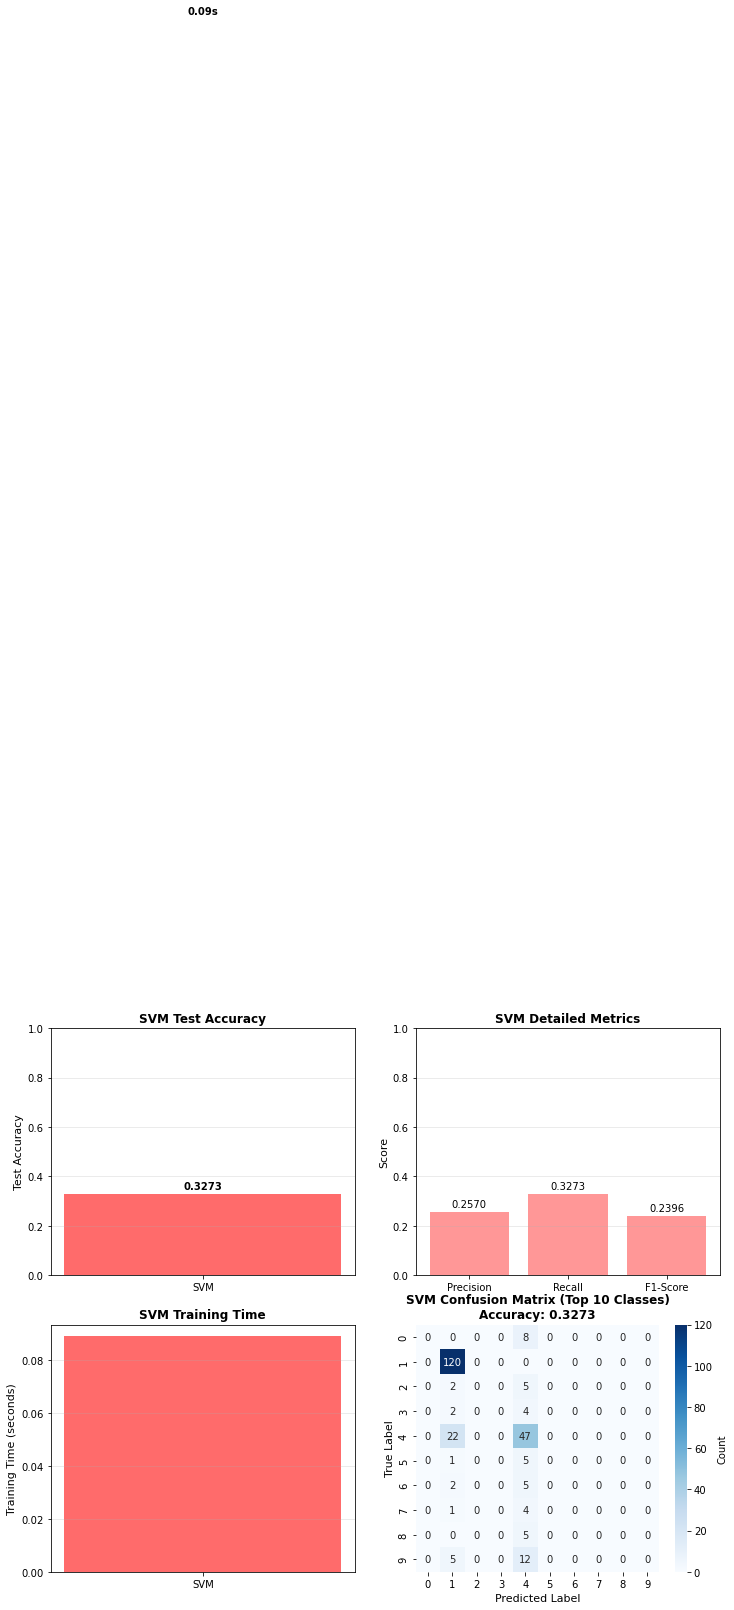

SVM visualization saved!


In [8]:
# Visualize SVM results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy comparison
axes[0, 0].bar(['SVM'], [svm_test_acc], color='#FF6B6B', width=0.4)
axes[0, 0].set_ylabel('Test Accuracy', fontsize=11)
axes[0, 0].set_title('SVM Test Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].text(0, svm_test_acc + 0.02, f'{svm_test_acc:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Detailed metrics
metrics = ['Precision', 'Recall', 'F1-Score']
metric_values = [svm_test_precision, svm_test_recall, svm_test_f1]
axes[0, 1].bar(metrics, metric_values, color='#FF6B6B', alpha=0.7)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('SVM Detailed Metrics', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(metric_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Training time
axes[1, 0].bar(['SVM'], [svm_train_time], color='#FF6B6B', width=0.4)
axes[1, 0].set_ylabel('Training Time (seconds)', fontsize=11)
axes[1, 0].set_title('SVM Training Time', fontsize=12, fontweight='bold')
axes[1, 0].text(0, svm_train_time + 0.5, f'{svm_train_time:.2f}s', ha='center', fontsize=10, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Confusion matrix
cm_svm = confusion_matrix(test_labels, svm_test_pred)
sns.heatmap(cm_svm[:10, :10], annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_title(f'SVM Confusion Matrix (Top 10 Classes)\nAccuracy: {svm_test_acc:.4f}', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=11)
axes[1, 1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('e:/jingxizhang/image-classification-project/figures/02_classical_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("SVM visualization saved!")